<a href="https://colab.research.google.com/github/Demi-Khaled/.Net/blob/main/Oxford_Pet_YOLO_Notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🎯 Oxford-IIIT Pet Detection with YOLOv11

Standalone YOLOv11 notebook with automatic results download.

# 🐾 Object Detection & Semantic Segmentation
## Oxford-IIIT Pet Dataset — YOLOv11 vs U-Net

This notebook implements and compares:
- **YOLOv11** — Object Detection (bounding boxes)
- **U-Net** — Semantic Segmentation (pixel-wise masks)

---

## 0. Install Dependencies

In [16]:
# All dependencies in one place — run once at session start
!pip install ultralytics torch torchvision torchaudio --quiet
!pip install opencv-python-headless matplotlib scikit-learn --quiet
!pip install tqdm albumentations torchmetrics --quiet
!pip install Pillow seaborn pandas --quiet

## 1. Imports & Configuration

In [17]:
# ── Standard library ─────────────────────────────────────────────────────────
import os
import random
import shutil
import tarfile
import time
import urllib.request
import xml.etree.ElementTree as ET
from collections import Counter
from pathlib import Path

# ── Third-party ───────────────────────────────────────────────────────────────
import cv2
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from PIL import Image
from tqdm import tqdm

# ── PyTorch ───────────────────────────────────────────────────────────────────
import torch
import torch.nn as nn
import torch.optim as optim
import albumentations as A
from albumentations.pytorch import ToTensorV2
from torch.utils.data import DataLoader, Dataset

# ── Scikit-learn ──────────────────────────────────────────────────────────────
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    precision_score,
    recall_score,
)

# ── Ultralytics ───────────────────────────────────────────────────────────────
from ultralytics import YOLO

In [18]:
# ── Reproducibility ───────────────────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device : {DEVICE}')
if torch.cuda.is_available():
    print(f'GPU    : {torch.cuda.get_device_name(0)}')

# ── Paths ─────────────────────────────────────────────────────────────────────
BASE_DIR    = Path('oxford_pet')
IMAGES_DIR  = BASE_DIR / 'images'
MASKS_DIR   = BASE_DIR / 'annotations' / 'trimaps'
XML_DIR     = BASE_DIR / 'annotations' / 'xmls'
YOLO_DIR    = Path('yolo_dataset')
RESULTS_DIR = Path('results')
RESULTS_DIR.mkdir(exist_ok=True)

# ── Hyperparameters ───────────────────────────────────────────────────────────
IMG_SIZE    = 256    # resize target (height = width)
BATCH_SIZE  = 16
YOLO_EPOCHS = 30
LR          = 1e-4
TRAIN_SPLIT = 0.80
VAL_SPLIT   = 0.10
# TEST_SPLIT  = remaining 10 %

NUM_CLASSES = 37    # 37 pet breeds in Oxford-IIIT

print('Configuration ready.')

Device : cuda
GPU    : Tesla T4
Configuration ready.


## 2. Download the Oxford-IIIT Pet Dataset

In [19]:
import urllib.request
import tarfile

BASE_DIR.mkdir(exist_ok=True)

URLS = {
    'images'     : 'https://www.robots.ox.ac.uk/~vgg/data/pets/data/images.tar.gz',
    'annotations': 'https://www.robots.ox.ac.uk/~vgg/data/pets/data/annotations.tar.gz',
}

for name, url in URLS.items():
    dest = BASE_DIR / f'{name}.tar.gz'
    if not dest.exists():
        print(f'Downloading {name}...')
        urllib.request.urlretrieve(url, dest)
    else:
        print(f'{name} archive already exists, skipping download.')

    extract_to = BASE_DIR / name
    if not extract_to.exists():
        print(f'Extracting {name}...')
        with tarfile.open(dest, 'r:gz') as tar:
            tar.extractall(BASE_DIR)
    else:
        print(f'{name} already extracted.')

print('Dataset ready.')
print('Images:    ', len(list(IMAGES_DIR.glob('*.jpg'))))
print('Trimaps:   ', len(list(MASKS_DIR.glob('*.png'))))
print('XML annots:', len(list(XML_DIR.glob('*.xml'))))

images archive already exists, skipping download.
images already extracted.
annotations archive already exists, skipping download.
annotations already extracted.
Dataset ready.
Images:     7390
Trimaps:    14780
XML annots: 3686


## 3. Exploratory Data Analysis

/tmp/ipykernel_12508/849506330.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(names, rotation=45, ha='right', fontsize=9)


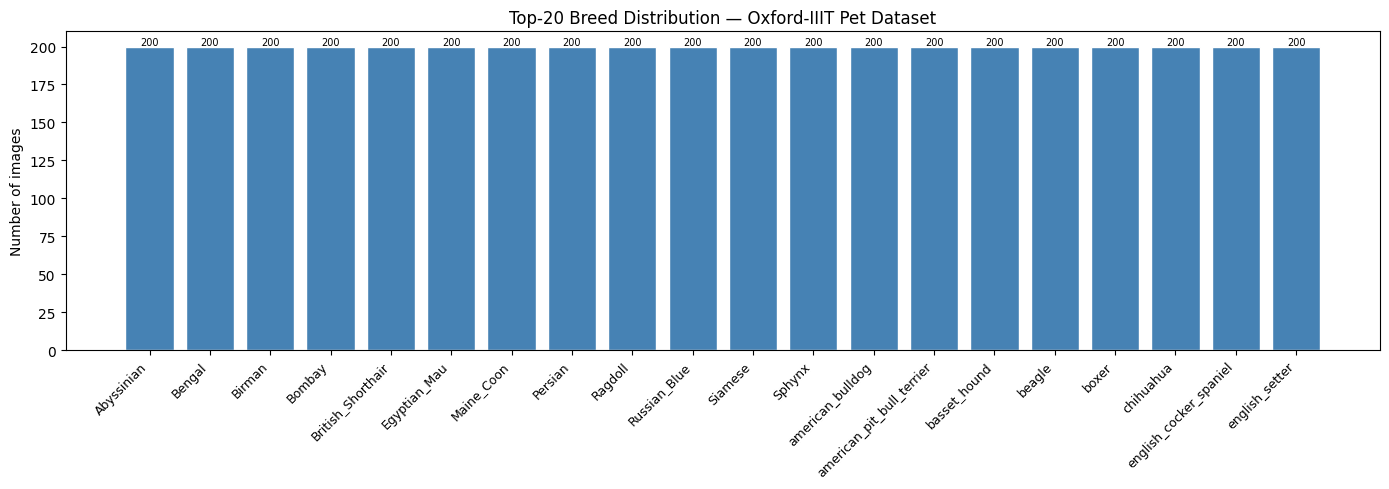

Total images : 7390
Unique breeds: 37


In [20]:
from collections import Counter

# Gather breed names from filenames  (format: Breed_Name_001.jpg)
all_images = sorted(IMAGES_DIR.glob('*.jpg'))
breeds = ['_'.join(p.stem.split('_')[:-1]) for p in all_images]
breed_counts = Counter(breeds)

# Plot top-20 breeds
top20 = breed_counts.most_common(20)
names, counts = zip(*top20)

fig, ax = plt.subplots(figsize=(14, 5))
bars = ax.bar(names, counts, color='steelblue', edgecolor='white')
ax.set_xticklabels(names, rotation=45, ha='right', fontsize=9)
ax.set_ylabel('Number of images')
ax.set_title('Top-20 Breed Distribution — Oxford-IIIT Pet Dataset')
ax.bar_label(bars, fontsize=7)
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'breed_distribution.png', dpi=150)
plt.show()

print(f'Total images : {len(all_images)}')
print(f'Unique breeds: {len(breed_counts)}')

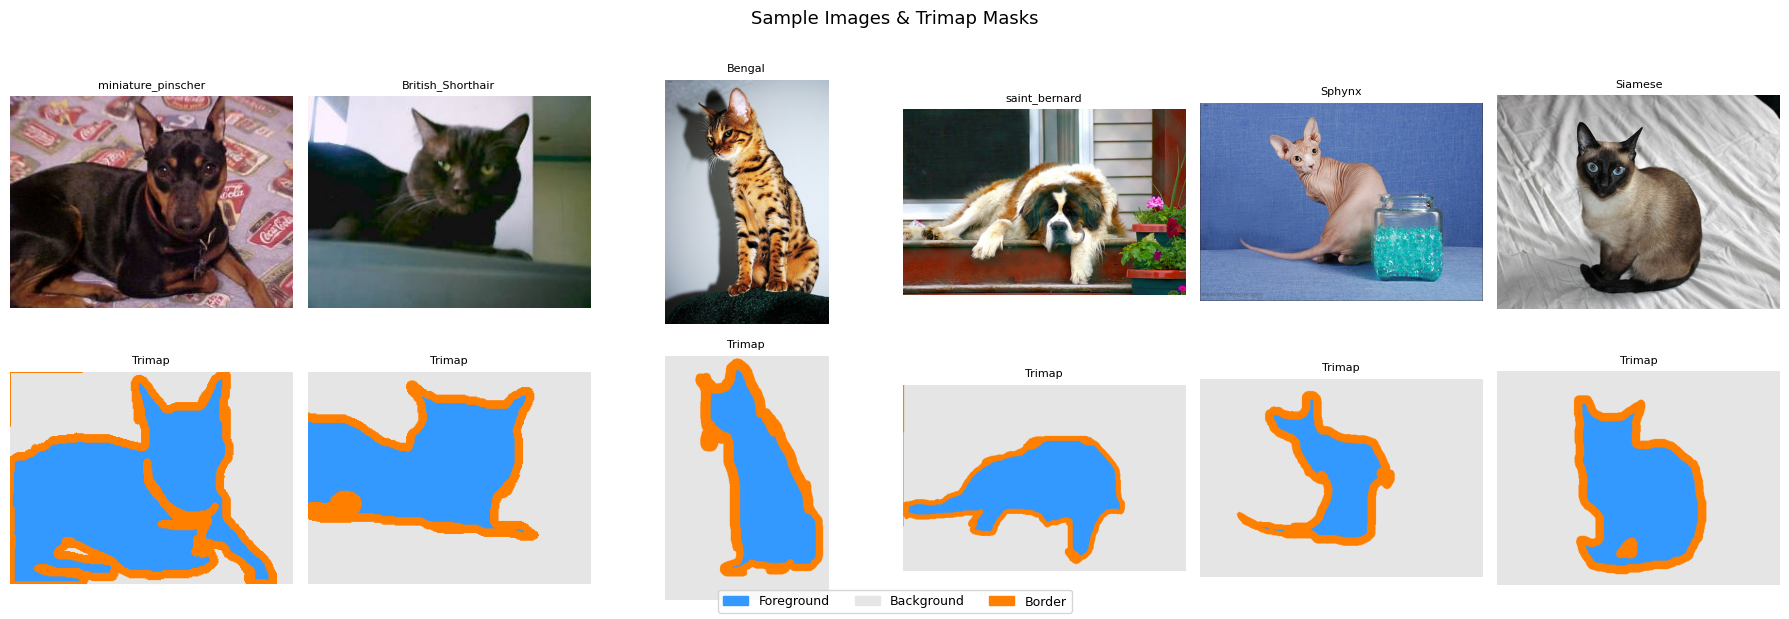

In [21]:
# Visualise sample images + trimap masks
samples = random.sample(all_images, 6)
fig, axes = plt.subplots(2, 6, figsize=(18, 6))

# Trimap legend: 1=foreground, 2=background, 3=border
CMAP = {1: [0.2, 0.6, 1.0], 2: [0.9, 0.9, 0.9], 3: [1.0, 0.5, 0.0]}

for col, img_path in enumerate(samples):
    img = np.array(Image.open(img_path).convert('RGB'))
    mask_path = MASKS_DIR / (img_path.stem + '.png')

    axes[0, col].imshow(img)
    axes[0, col].set_title('_'.join(img_path.stem.split('_')[:-1]), fontsize=8)
    axes[0, col].axis('off')

    if mask_path.exists():
        mask = np.array(Image.open(mask_path))
        coloured = np.zeros((*mask.shape, 3))
        for v, c in CMAP.items():
            coloured[mask == v] = c
        axes[1, col].imshow(coloured)
    else:
        axes[1, col].text(0.5, 0.5, 'No mask', ha='center', va='center')
    axes[1, col].set_title('Trimap', fontsize=8)
    axes[1, col].axis('off')

patches = [mpatches.Patch(color=c, label=l)
           for l, c in zip(['Foreground', 'Background', 'Border'], CMAP.values())]
fig.legend(handles=patches, loc='lower center', ncol=3, fontsize=9)
plt.suptitle('Sample Images & Trimap Masks', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'sample_images_masks.png', dpi=150)
plt.show()

## 4. Data Preprocessing
### 4.1 Split Dataset

In [22]:
# Keep only images that have a corresponding trimap mask
valid_images = [p for p in all_images if (MASKS_DIR / (p.stem + '.png')).exists()]
random.shuffle(valid_images)

n = len(valid_images)
n_train = int(n * TRAIN_SPLIT)
n_val   = int(n * VAL_SPLIT)

train_imgs = valid_images[:n_train]
val_imgs   = valid_images[n_train:n_train + n_val]
test_imgs  = valid_images[n_train + n_val:]

print(f'Total valid : {n}')
print(f'Train       : {len(train_imgs)}')
print(f'Validation  : {len(val_imgs)}')
print(f'Test        : {len(test_imgs)}')

Total valid : 7390
Train       : 5912
Validation  : 739
Test        : 739


### 4.2 Augmentation Pipelines

In [23]:
train_transform = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.1),
    A.RandomBrightnessContrast(p=0.3),
    A.HueSaturationValue(p=0.2),
    A.Rotate(limit=15, p=0.3),
    A.Normalize(mean=(0.485, 0.456, 0.406),
                std =(0.229, 0.224, 0.225)),
    ToTensorV2(),
])

val_transform = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.Normalize(mean=(0.485, 0.456, 0.406),
                std =(0.229, 0.224, 0.225)),
    ToTensorV2(),
])

print('Augmentation pipelines defined.')

Augmentation pipelines defined.


### 4.3 Dataset Classes

## 6. YOLOv11 — Object Detection
### 6.1 Prepare YOLO Dataset (from XML annotations)

In [24]:
# Build breed → class-id mapping
all_xmls = sorted(XML_DIR.glob('*.xml'))
breed_set = sorted({'_'.join(p.stem.split('_')[:-1]) for p in all_xmls})
breed2id  = {b: i for i, b in enumerate(breed_set)}
print(f'Breeds with XML annotations: {len(breed2id)}')

# ── Helper: VOC XML → YOLO label lines ───────────────────────────────────────
def xml_to_yolo(xml_path: Path) -> list[str]:
    """Parse a Pascal-VOC XML file and return YOLO-format label strings."""
    tree  = ET.parse(xml_path)
    root  = tree.getroot()
    size  = root.find('size')
    W     = int(size.find('width').text)
    H     = int(size.find('height').text)
    breed = '_'.join(xml_path.stem.split('_')[:-1])
    cls   = breed2id.get(breed, 0)

    lines = []
    for obj in root.findall('object'):
        bb   = obj.find('bndbox')
        xmin = float(bb.find('xmin').text)
        ymin = float(bb.find('ymin').text)
        xmax = float(bb.find('xmax').text)
        ymax = float(bb.find('ymax').text)
        cx   = ((xmin + xmax) / 2) / W
        cy   = ((ymin + ymax) / 2) / H
        bw   = (xmax - xmin) / W
        bh   = (ymax - ymin) / H
        lines.append(f'{cls} {cx:.6f} {cy:.6f} {bw:.6f} {bh:.6f}')
    return lines


def populate_split(img_paths: list[Path], split: str) -> None:
    """Copy images and write label files for one data split."""
    img_out = YOLO_DIR / split / 'images'
    lbl_out = YOLO_DIR / split / 'labels'
    img_out.mkdir(parents=True, exist_ok=True)
    lbl_out.mkdir(parents=True, exist_ok=True)

    copied = 0
    for img_path in tqdm(img_paths, desc=f'  {split:5s}', leave=False):
        xml_path = XML_DIR / (img_path.stem + '.xml')
        if not xml_path.exists():
            continue
        lines = xml_to_yolo(xml_path)
        if not lines:
            continue
        shutil.copy(img_path, img_out / img_path.name)
        (lbl_out / (img_path.stem + '.txt')).write_text('\n'.join(lines))
        copied += 1
    print(f'  {split:10s}: {copied} samples')


print('Populating YOLO dataset splits...')
populate_split(train_imgs, 'train')
populate_split(val_imgs,   'val')
populate_split(test_imgs,  'test')
print('Done.')

Breeds with XML annotations: 37
Populating YOLO dataset splits...


  train     : 2962 samples


  val       : 373 samples


  test      : 351 samples
Done.


In [25]:
# ── Write dataset.yaml ────────────────────────────────────────────────────────
yaml_content = '\n'.join([
    f'path: {YOLO_DIR.resolve()}',
    'train: train/images',
    'val:   val/images',
    'test:  test/images',
    f'nc: {len(breed2id)}',
    f'names: {list(breed2id.keys())}',
])

yaml_path = YOLO_DIR / 'dataset.yaml'
yaml_path.write_text(yaml_content)
print(yaml_path.read_text())

path: /content/yolo_dataset
train: train/images
val:   val/images
test:  test/images
nc: 37
names: ['Abyssinian', 'Bengal', 'Birman', 'Bombay', 'British_Shorthair', 'Egyptian_Mau', 'Maine_Coon', 'Persian', 'Ragdoll', 'Russian_Blue', 'Siamese', 'Sphynx', 'american_bulldog', 'american_pit_bull_terrier', 'basset_hound', 'beagle', 'boxer', 'chihuahua', 'english_cocker_spaniel', 'english_setter', 'german_shorthaired', 'great_pyrenees', 'havanese', 'japanese_chin', 'keeshond', 'leonberger', 'miniature_pinscher', 'newfoundland', 'pomeranian', 'pug', 'saint_bernard', 'samoyed', 'scottish_terrier', 'shiba_inu', 'staffordshire_bull_terrier', 'wheaten_terrier', 'yorkshire_terrier']


### 6.2 Train YOLOv11

In [26]:
yolo_model = YOLO('yolo11n.pt')

yolo_results = yolo_model.train(
    data     = str(yaml_path),
    epochs   = YOLO_EPOCHS,
    imgsz    = IMG_SIZE,
    batch    = BATCH_SIZE,
    lr0      = LR,
    device   = 0 if torch.cuda.is_available() else 'cpu',
    project  = str(RESULTS_DIR),
    name     = 'yolo11_pets',
    exist_ok = True,
    verbose  = False,
)

print('YOLOv11 training complete.')

Ultralytics 8.4.50 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=yolo_dataset/dataset.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=256, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.0001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolo11_pets, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100,

### 6.3 YOLOv11 Evaluation

In [28]:
import os

# The trainer saves results in 'runs/detect/{name}' relative to the project directory
# Based on the logs, the weights are located in runs/detect/results/yolo11_pets/weights/

best_weights = Path('runs/detect/results/yolo11_pets/weights/best.pt')

if not best_weights.exists():
    # Fallback search if pathing differs due to environment
    print("Warning: Standard path not found, searching for best.pt...")
    possible_weights = list(Path('.').rglob('best.pt'))
    if possible_weights:
        best_weights = possible_weights[0]

yolo_best = YOLO(str(best_weights))
print(f'Loaded weights from: {best_weights}')

Loaded weights from: runs/detect/results/yolo11_pets/weights/best.pt


In [29]:
val_metrics = yolo_best.val(
    data   = str(yaml_path),
    split  = 'test',
    imgsz  = IMG_SIZE,
    device = 0 if torch.cuda.is_available() else 'cpu',
)

yolo_map50    = val_metrics.box.map50
yolo_map5095  = val_metrics.box.map
yolo_precision = val_metrics.box.mp
yolo_recall    = val_metrics.box.mr

print('\n── YOLOv11 Test Results ──────────────────')
print(f'  mAP@0.50      : {yolo_map50:.4f}')
print(f'  mAP@0.50:0.95 : {yolo_map5095:.4f}')
print(f'  Precision      : {yolo_precision:.4f}')
print(f'  Recall         : {yolo_recall:.4f}')

Ultralytics 8.4.50 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11n summary (fused): 101 layers, 2,589,367 parameters, 0 gradients, 6.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1579.1±932.1 MB/s, size: 139.3 KB)
val: Scanning /content/yolo_dataset/test/labels... 351 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 351/351 957.8it/s 0.4s
val: New cache created: /content/yolo_dataset/test/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 22/22 4.9it/s 4.5s
                   all        351        351      0.817      0.758      0.855      0.728
            Abyssinian         13         13      0.804      0.632      0.882      0.828
                Bengal          8          8       0.59       0.75      0.502      0.423
                Birman         14         14      0.857      0.857      0.838       0.69
                Bombay          8          8      0.962          1      

In [30]:
# ── Metric helper functions ───────────────────────────────────────────────────

def box_iou(boxA: list, boxB: list) -> float:
    """Compute IoU between two boxes in [xmin, ymin, xmax, ymax] format."""
    xA = max(boxA[0], boxB[0]);  yA = max(boxA[1], boxB[1])
    xB = min(boxA[2], boxB[2]);  yB = min(boxA[3], boxB[3])
    inter = max(0, xB - xA) * max(0, yB - yA)
    areaA = (boxA[2] - boxA[0]) * (boxA[3] - boxA[1])
    areaB = (boxB[2] - boxB[0]) * (boxB[3] - boxB[1])
    return inter / (areaA + areaB - inter + 1e-6)


def dice_from_iou(iou: float) -> float:
    """Derive Dice coefficient from IoU: Dice = 2*IoU / (1 + IoU)."""
    return (2 * iou) / (1 + iou + 1e-6)


def load_gt_boxes(img_path: Path) -> tuple[list, list]:
    """Return (boxes, classes) from the corresponding YOLO label file."""
    lbl_path = YOLO_DIR / 'test' / 'labels' / (img_path.stem + '.txt')
    if not lbl_path.exists():
        return [], []
    boxes, classes = [], []
    for line in lbl_path.read_text().strip().splitlines():
        parts = line.split()
        cls, cx, cy, bw, bh = int(parts[0]), *map(float, parts[1:])
        xmin = (cx - bw / 2) * IMG_SIZE
        ymin = (cy - bh / 2) * IMG_SIZE
        xmax = (cx + bw / 2) * IMG_SIZE
        ymax = (cy + bh / 2) * IMG_SIZE
        boxes.append([xmin, ymin, xmax, ymax])
        classes.append(cls)
    return boxes, classes


print('Metric helpers defined.')

Metric helpers defined.


In [31]:
# ── Run inference on test set & collect predictions ───────────────────────────
test_image_paths = list((YOLO_DIR / 'test' / 'images').glob('*.jpg'))

true_classes, pred_classes = [], []
iou_scores, dice_scores   = [], []

for img_path in tqdm(test_image_paths, desc='Collecting predictions'):
    gt_boxes, gt_classes = load_gt_boxes(img_path)
    if not gt_boxes:
        continue

    result    = yolo_best.predict(str(img_path), verbose=False, conf=0.25, imgsz=IMG_SIZE)[0]
    pred_xyxy = result.boxes.xyxy.cpu().numpy()   # shape (N, 4)
    pred_cls  = result.boxes.cls.cpu().numpy().astype(int)

    for gt_box, gt_cls in zip(gt_boxes, gt_classes):
        if len(pred_xyxy) == 0:
            # No prediction → treat as background (class -1 is ignored below)
            continue
        ious = [box_iou(gt_box, pb.tolist()) for pb in pred_xyxy]
        best_idx = int(np.argmax(ious))
        best_iou = ious[best_idx]

        true_classes.append(gt_cls)
        pred_classes.append(pred_cls[best_idx])
        iou_scores.append(best_iou)
        dice_scores.append(dice_from_iou(best_iou))

print(f'Collected {len(true_classes)} matched predictions.')

Collected 344 matched predictions.


In [32]:
# ── Compute & display evaluation summary ─────────────────────────────────────
accuracy   = accuracy_score(true_classes, pred_classes)
precision  = precision_score(true_classes, pred_classes, average='weighted', zero_division=0)
recall_val = recall_score(true_classes, pred_classes, average='weighted', zero_division=0)
mean_iou   = float(np.mean(iou_scores))
mean_dice  = float(np.mean(dice_scores))

metrics_df = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision (weighted)', 'Recall (weighted)',
               'Mean IoU', 'Mean Dice Score',
               'mAP@0.50', 'mAP@0.50:0.95'],
    'Value' : [accuracy, precision, recall_val,
               mean_iou, mean_dice,
               yolo_map50, yolo_map5095],
})
metrics_df['Value'] = metrics_df['Value'].map('{:.4f}'.format)

print('\n── YOLOv11 Evaluation Summary ───────────────')
print(metrics_df.to_string(index=False))

metrics_df.to_csv(RESULTS_DIR / 'yolo_evaluation_summary.csv', index=False)
print(f'\nSaved → {RESULTS_DIR / "yolo_evaluation_summary.csv"}')


── YOLOv11 Evaluation Summary ───────────────
              Metric  Value
            Accuracy 0.7936
Precision (weighted) 0.8115
   Recall (weighted) 0.7936
            Mean IoU 0.1725
     Mean Dice Score 0.2535
            mAP@0.50 0.8550
       mAP@0.50:0.95 0.7277

Saved → results/yolo_evaluation_summary.csv


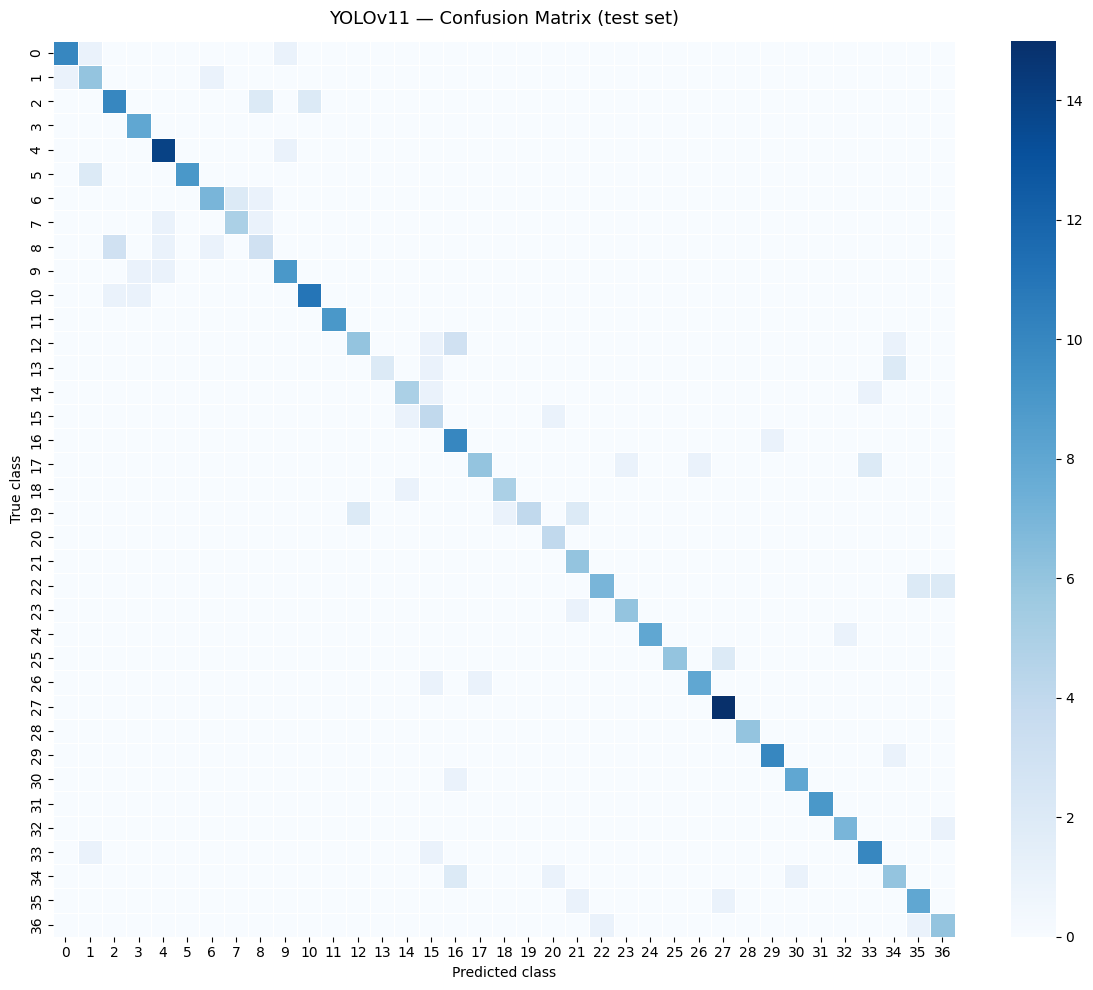

In [33]:
cm = confusion_matrix(true_classes, pred_classes)

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(
    cm,
    annot=len(breed2id) <= 20,   # annotate cells only when <= 20 classes
    fmt='d',
    cmap='Blues',
    linewidths=0.5,
    ax=ax,
)
ax.set_title('YOLOv11 — Confusion Matrix (test set)', fontsize=13, pad=12)
ax.set_xlabel('Predicted class')
ax.set_ylabel('True class')
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'confusion_matrix.png', dpi=150)
plt.show()

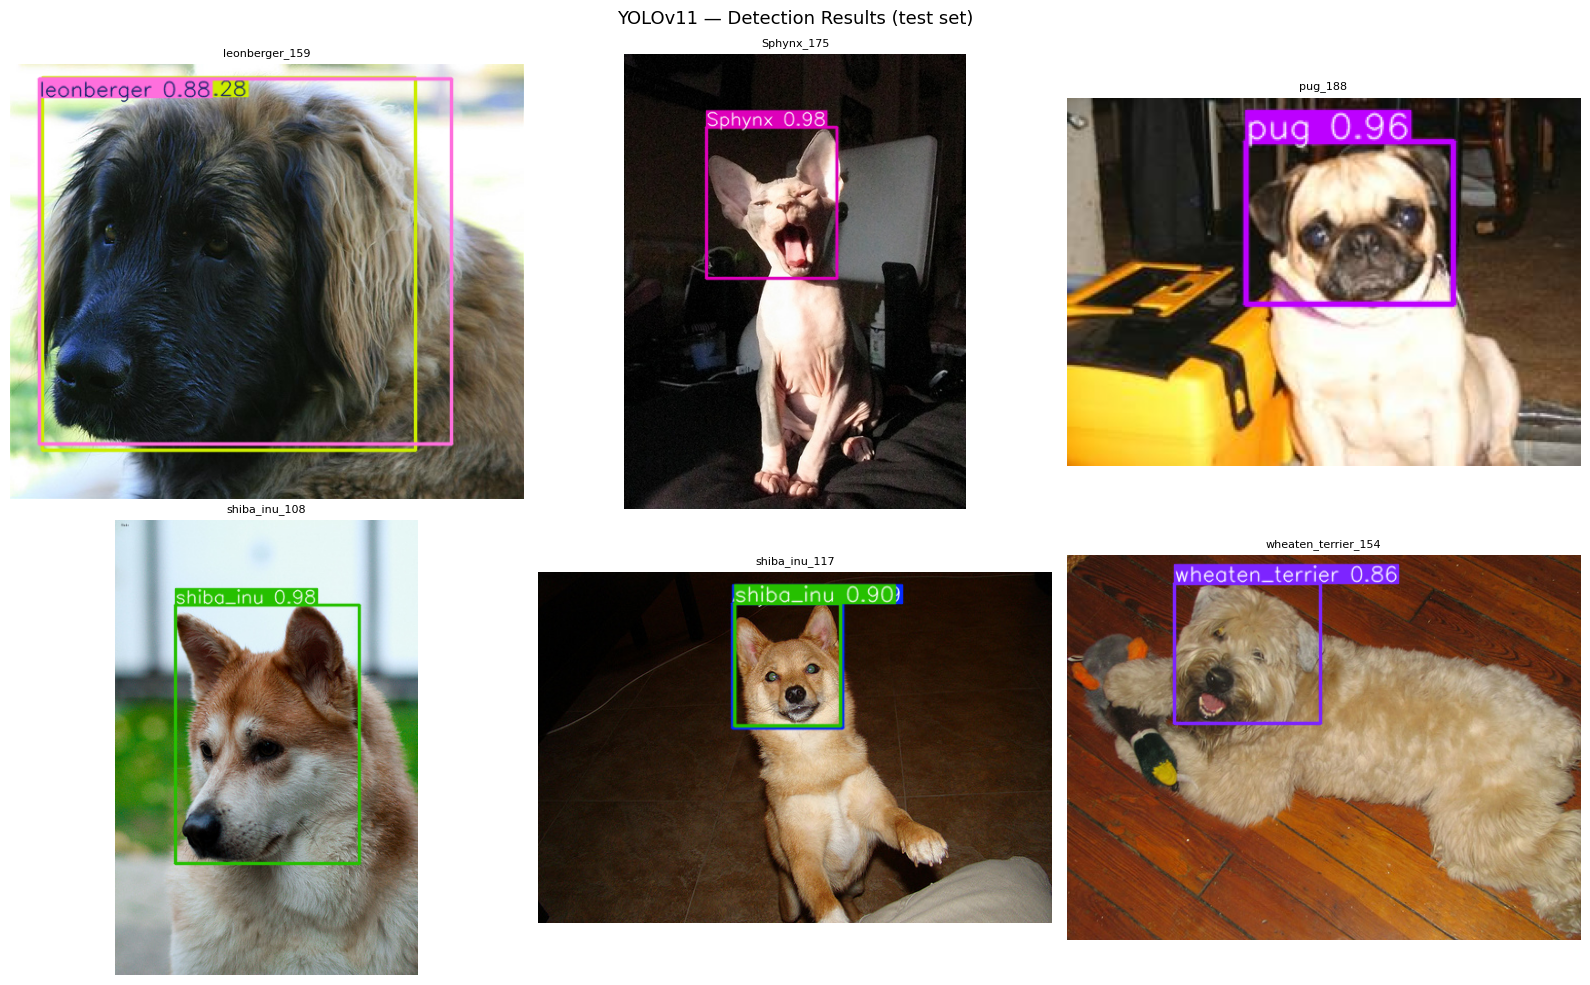

In [34]:
sample_test_imgs = random.sample(test_image_paths, min(6, len(test_image_paths)))

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
for ax, img_path in zip(axes.flat, sample_test_imgs):
    result  = yolo_best.predict(str(img_path), verbose=False, conf=0.25)[0]
    plotted = result.plot()   # BGR numpy array with boxes drawn
    ax.imshow(cv2.cvtColor(plotted, cv2.COLOR_BGR2RGB))
    ax.set_title(Path(img_path).stem[:30], fontsize=8)
    ax.axis('off')

plt.suptitle('YOLOv11 — Detection Results (test set)', fontsize=13)
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'yolo_predictions.png', dpi=150)
plt.show()

In [35]:
archive_path = shutil.make_archive('YOLO_Results', 'zip', str(RESULTS_DIR))
print(f'Archive created: {archive_path}')

# ── Auto-download in Colab (no-op in other environments) ─────────────────────
try:
    from google.colab import files
    files.download(archive_path)
    print('Download triggered (Colab).')
except ImportError:
    print('Not running in Colab — find the archive at:', archive_path)

Archive created: /content/YOLO_Results.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Download triggered (Colab).
